
Primeros registros con componentes principales:
   DEPTO  DEPTODESC  MUNIC  MUNICDESC  DISTO  DISTODESC  GHS_DUG_L1  \
0      1          0      1          2      1         13           3   
1      1          0      1          2      1         13           3   
2      1          0      1          2      1         13           3   
3      1          0      1          2      1         13           3   
4      1          0      1          2      1         13           3   

   GHS_DUG_L2  INFO_TOTAL       PC1      PC2       PC3       PC4       PC5  \
0          30           1 -2.056407  2.56656 -2.246212 -0.895343 -1.226242   
1          30           1 -2.056407  2.56656 -2.246212 -0.895343 -1.226242   
2          30           1 -2.056407  2.56656 -2.246212 -0.895343 -1.226242   
3          30           1 -2.056407  2.56656 -2.246212 -0.895343 -1.226242   
4          30           1 -2.056407  2.56656 -2.246212 -0.895343 -1.226242   

        PC6       PC7       PC8       PC9  
0  0.112803

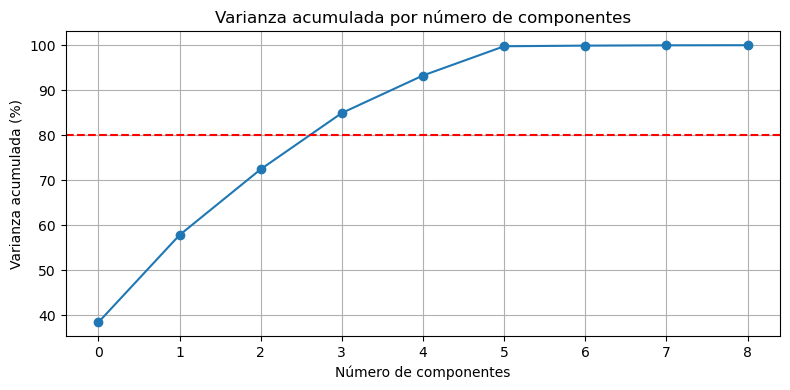

In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

# 1. Cargar datos
ruta_csv = r"C:\Users\xcero\Documents\Machine Learning\datos.csv"
df = pd.read_csv(ruta_csv, low_memory=False)

# 2. Limpiar nombres de columnas
df.columns = df.columns.str.strip().str.upper()

# 3. Seleccionar columnas útiles para PCA
columnas_pca = [
    "DEPTO", "DEPTODESC", "MUNIC", "MUNICDESC", "DISTO", "DISTODESC",
    "GHS_DUG_L1", "GHS_DUG_L2", "INFO_TOTAL"
]

# 4. Copiar y codificar texto categórico
df_pca = df[columnas_pca].copy()
label_cols = ["DEPTODESC", "MUNICDESC", "DISTODESC"]
for col in label_cols:
    if col in df_pca.columns:
        le = LabelEncoder()
        df_pca[col] = le.fit_transform(df_pca[col].astype(str))

# 5. Convertir todo a numérico
for col in df_pca.columns:
    df_pca[col] = pd.to_numeric(df_pca[col], errors="coerce")

# 6. Eliminar filas con nulos
df_pca.dropna(inplace=True)

# 7. Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# 8. Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 9. Crear DataFrame con componentes principales
df_componentes = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
df_resultado = df_pca.reset_index(drop=True).join(df_componentes)

# 10. Tabla de valores propios (eigenvalores)
tabla_valores_propios = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_))],
    "Valor propio": pca.explained_variance_,
    "Varianza explicada (%)": pca.explained_variance_ratio_ * 100,
    "Varianza acumulada (%)": np.cumsum(pca.explained_variance_ratio_) * 100
})

# 11. Tabla de vectores propios (eigenvectores)
tabla_vectores_propios = pd.DataFrame(
    pca.components_,
    columns=df_pca.columns,
    index=[f"PC{i+1}" for i in range(len(pca.components_))]
)

# 12. Mostrar resultados
print("\nPrimeros registros con componentes principales:")
print(df_resultado.head())

print("\nTabla de valores propios:")
print(tabla_valores_propios.head())

print("\nTabla de vectores propios:")
print(tabla_vectores_propios.head())

# 13. Graficar varianza acumulada
plt.figure(figsize=(8, 4))
plt.plot(tabla_valores_propios["Varianza acumulada (%)"], marker='o')
plt.axhline(y=80, color='r', linestyle='--')
plt.title("Varianza acumulada por número de componentes")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada (%)")
plt.grid(True)
plt.tight_layout()
plt.show()




Interpretación:
- Los primeros 4 componentes explican más del 80% de la variabilidad del conjunto de datos.
- Puedes reducir de 9 variables originales a 4 componentes sin perder estructura significativa.
- Esto mejora la eficiencia y claridad del clustering.

3. Tabla de vectores propios (eigenvectores)
Cada fila representa un componente principal (PC1, PC2, etc.), y cada columna muestra cuánto contribuye cada variable original a ese componente.
Ejemplo: PC1
- Alta carga en DEPTODESC, MUNICDESC, DISTODESC (≈ 0.5)
- También contribuyen GHS_DUG_L1 y GHS_DUG_L2 (≈ 0.3)
- INFO_TOTAL tiene carga casi nula (-0.019)
Interpretación:
- PC1 representa una combinación fuerte de variables geográficas codificadas.
- PC2 está dominado por GHS_DUG_L1, GHS_DUG_L2, y algo de INFO_TOTAL.
- PC3 mezcla DEPTO, DISTO, y MUNIC con signos opuestos, lo que sugiere contraste entre regiones.

 ¿Cómo esto sirve para clustering?
- Reducción de dimensionalidad: Usar PC1 a PC4 evita redundancia y ruido.
- Mejor separación: Los componentes capturan patrones latentes, ideales para algoritmos como KMeans, DBSCAN o HDBSCAN.
- Escalabilidad: Menos variables → menor costo computacional.
- Interpretabilidad: Puedes analizar qué variables influyen en cada grupo según los vectores propios.

Puedo ayudarte a aplicar clustering directamente sobre PC1 a PC4, evaluar la calidad de los grupos y vincularlos a mapas en ArcGIS Pro. Solo dime si prefieres KMeans, DBSCAN o HDBSCAN para comenzar.


# Diccionario de Variables Usadas en PCA

| Mnemónico     | Etiqueta                          |
|---------------|-----------------------------------|
| DEPTO         | Clave del departamento            |
| DEPTODESC     | Departamento de residencia        |
| MUNIC         | Clave del municipio               |
| MUNICDESC     | Municipio de residencia           |
| DISTO         | Clave del distrito                |
| DISTODESC     | Distrito de residencia            |
| GHS_DUG_L1    | Grado de urbanización - Nivel 1   |
| GHS_DUG_L2    | Grado de urbanización - Nivel 2   |
| INFO_TOTAL    | Tipo de hogar (ocupación total)   |

---

# Interpretación de Componentes Principales (PCA)

| Componente | Variables dominantes                                      | Interpretación sugerida                                |
|------------|-----------------------------------------------------------|--------------------------------------------------------|
| **PC1**    | DEPTODESC, MUNICDESC, DISTODESC (≈ 0.5), GHS_DUG_L1/L2 (≈ 0.3) | Estructura geográfica y grado de urbanización          |
| **PC2**    | GHS_DUG_L1, GHS_DUG_L2 (≈ 0.6), INFO_TOTAL (≈ 0.3)         | Clasificación urbana y tipo de hogar                   |
| **PC3**    | DEPTO, DISTO (≈ 0.56), MUNIC (≈ -0.50)                     | Contraste entre regiones y densidad territorial        |
| **PC4**    | DISTO (≈ -0.50), INFO_TOTAL (≈ 0.74)                       | Diferencias en tipo de hogar y entorno inmediato       |

---

**Notas:**
- Las variables dominantes se identifican por sus mayores cargas absolutas en los vectores propios.
- Estas interpretaciones ayudan a entender qué representa cada eje en los gráficos de dispersión y cómo se relacionan con los patrones de agrupamiento.

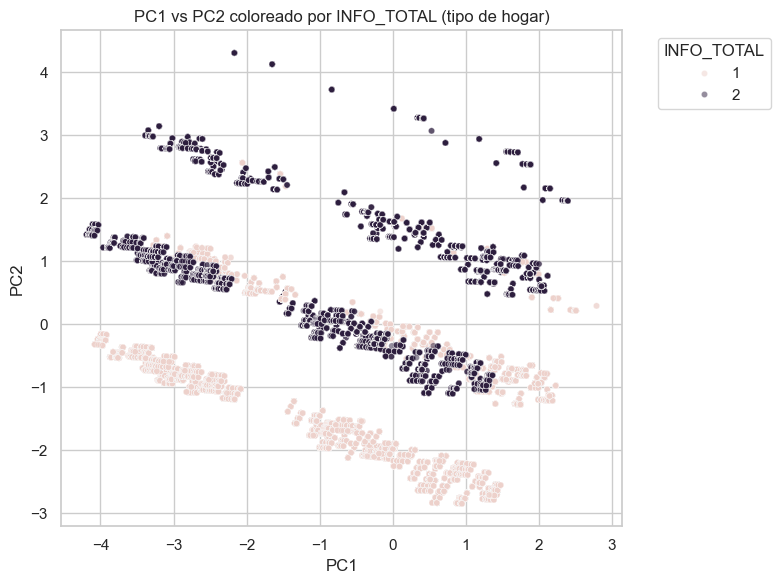

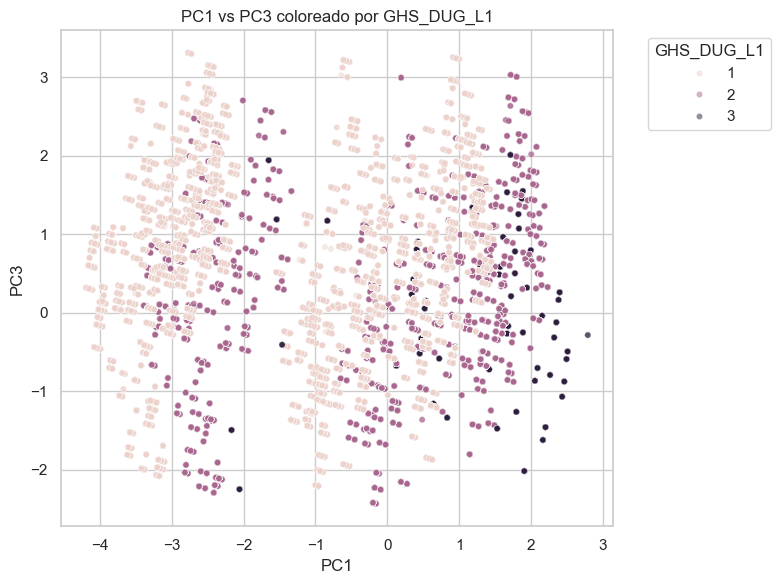

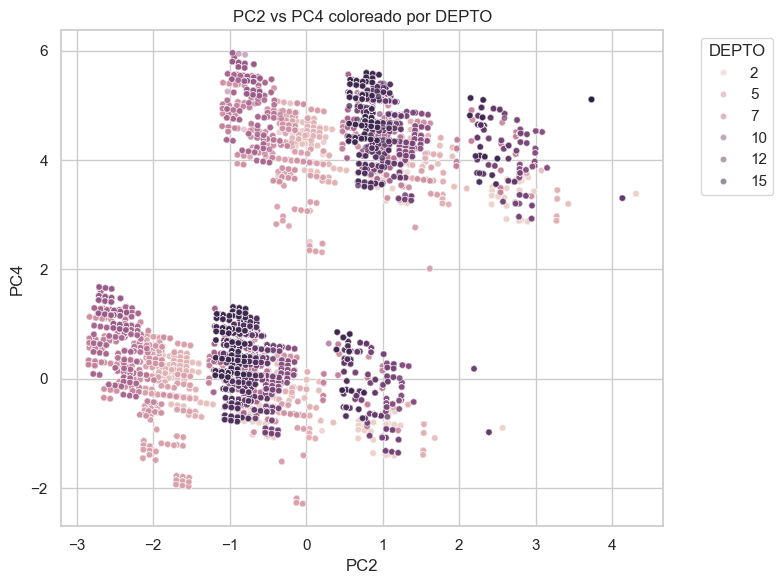

In [7]:
## import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el DataFrame con componentes principales
# Asegúrate de que df_resultado contenga las columnas: PC1, PC2, PC3, PC4, HOGAR_TIPO, GHS_DUG_L1, DEPTO
# Si no lo tienes cargado, vuelve a unir df_componentes con las columnas originales necesarias

# 2. Configurar estilo de gráficos
sns.set(style="whitegrid", palette="muted")

# 3. Gráfico: PC1 vs PC2 coloreado por HOGAR_TIPO
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_resultado, x="PC1", y="PC2", hue="INFO_TOTAL", alpha=0.5, s=20)
plt.title("PC1 vs PC2 coloreado por INFO_TOTAL (tipo de hogar)")
plt.legend(title="INFO_TOTAL", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Gráfico: PC1 vs PC3 coloreado por GHS_DUG_L1
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_resultado, x="PC1", y="PC3", hue="GHS_DUG_L1", alpha=0.5, s=20)
plt.title("PC1 vs PC3 coloreado por GHS_DUG_L1")
plt.legend(title="GHS_DUG_L1", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Gráfico: PC2 vs PC4 coloreado por DEPTO
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_resultado, x="PC2", y="PC4", hue="DEPTO", alpha=0.5, s=20)
plt.title("PC2 vs PC4 coloreado por DEPTO")
plt.legend(title="DEPTO", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

El Grafico 1 - Agrupamientos: Si ves nubes de puntos bien separadas, es una señal de que hay estructura latente útil para clustering.


In [4]:
print("\nResumen estadístico de los componentes principales:")
print(df_resultado.describe())



Resumen estadístico de los componentes principales:
              DEPTO     DEPTODESC         MUNIC     MUNICDESC         DISTO  \
count  6.029976e+06  6.029976e+06  6.029976e+06  6.029976e+06  6.029976e+06   
mean   6.615794e+00  7.934177e+00  2.124414e+00  2.359172e+01  1.013636e+01   
std    3.688201e+00  3.931558e+00  1.316147e+00  1.248326e+01  6.187666e+00   
min    1.000000e+00  0.000000e+00  1.000000e+00  0.000000e+00  1.000000e+00   
25%    4.000000e+00  5.000000e+00  1.000000e+00  1.300000e+01  5.000000e+00   
50%    6.000000e+00  1.000000e+01  2.000000e+00  2.700000e+01  1.000000e+01   
75%    9.000000e+00  1.100000e+01  3.000000e+00  3.400000e+01  1.500000e+01   
max    1.500000e+01  1.400000e+01  6.000000e+00  4.400000e+01  3.300000e+01   

          DISTODESC    GHS_DUG_L1    GHS_DUG_L2    INFO_TOTAL           PC1  \
count  6.029976e+06  6.029976e+06  6.029976e+06  6.029976e+06  6.029976e+06   
mean   1.456265e+02  2.076943e+00  2.195487e+01  1.030943e+00 -1.922560e-15  

In [ ]:
Media ≈ 0 y desviación estándar decreciente
• 	Las medias de  a  están cerca de cero, como se espera tras estandarización.
• 	Las desviaciones estándar disminuyen de  a , lo que indica que cada componente explica menos varianza que el anterior.
2. Rango de valores
• 	 tiene el mayor rango (mínimo -4.18, máximo 2.79), lo que refleja que es el componente más informativo.
• 	 tiene un rango muy estrecho (≈ ±0.2), lo que sugiere que aporta muy poca variabilidad.

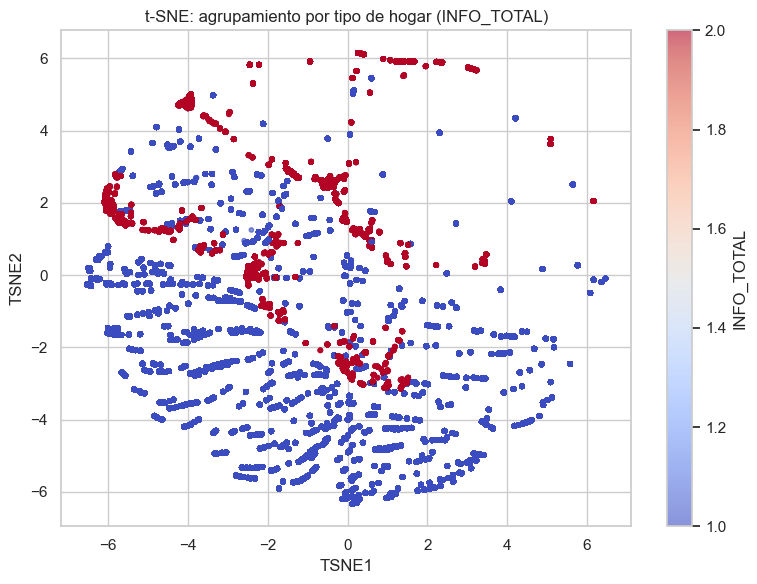

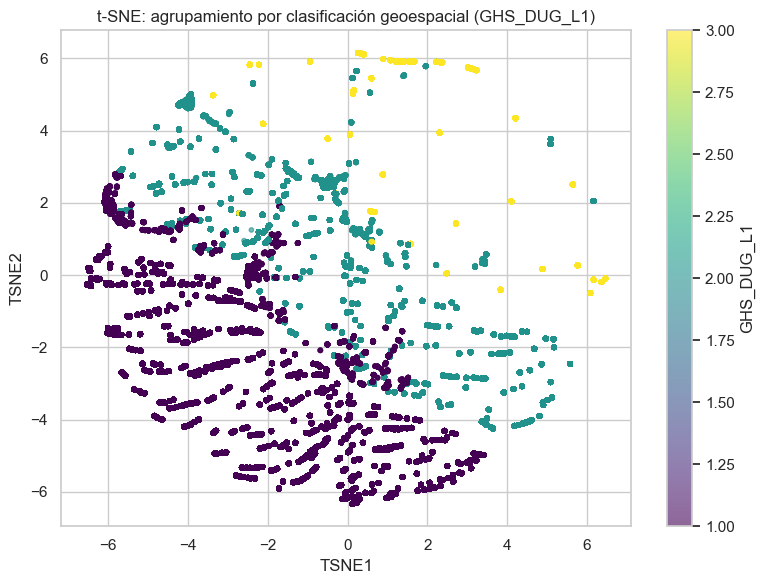

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Seleccionar componentes principales
X = df_resultado[["PC1", "PC2", "PC3", "PC4"]].copy()

# 2. Aplicar t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X)

# 3. Crear DataFrame con resultados
df_tsne = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
df_tsne["INFO_TOTAL"] = df_resultado["INFO_TOTAL"].values
df_tsne["DEPTO"] = df_resultado["DEPTO"].values
df_tsne["GHS_DUG_L1"] = df_resultado["GHS_DUG_L1"].values

# 4. Visualización: t-SNE coloreado por tipo de hogar
plt.figure(figsize=(8, 6))
plt.scatter(df_tsne["TSNE1"], df_tsne["TSNE2"], c=df_tsne["INFO_TOTAL"], cmap="coolwarm", s=10, alpha=0.6)
plt.title("t-SNE: agrupamiento por tipo de hogar (INFO_TOTAL)")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.colorbar(label="INFO_TOTAL")
plt.tight_layout()
plt.show()

# 5. Visualización: t-SNE coloreado por GHS_DUG_L1
plt.figure(figsize=(8, 6))
plt.scatter(df_tsne["TSNE1"], df_tsne["TSNE2"], c=df_tsne["GHS_DUG_L1"], cmap="viridis", s=10, alpha=0.6)
plt.title("t-SNE: agrupamiento por clasificación geoespacial (GHS_DUG_L1)")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.colorbar(label="GHS_DUG_L1")
plt.tight_layout()
plt.show()